# Goals of this analysis
The graphs we are trying to generate
1. Initial distribution of computing time
2. Distribution of computing time after splitting on user device computation time out
3. Distribution of computing time after removing running proof generating in parallel 

We also need to see how long each of these steps take for 5 million votes. And we need to see how long the final time is when we start to speed up message processing.

# How to get the data
Setup the three files to collect the runs you want.
```
__custom_benchmarks__/initial_proof_gen_work.ts
__custom_benchmarks__/split_out_client_side_work.ts
__custom_benchmarks__/parallelized_proof_gen.ts
```

Run them with the following commands
```
yarn run proof_bench_1
yarn run proof_bench_2
yarn run proof_bench_3
```

Move the generated json files to a separate folder for analysis.

Enter the file names below

In [1]:
PROOF_BENCH_1_OUTPUT_FILE = "Profile_initial_proof_gen_work.json"
PROOF_BENCH_2_OUTPUT_FILE = "Profile_split_out_client_side_work.json"
PROOF_BENCH_3_OUTPUT_FILE = "Profile_parallelized_proof_gen.json"

Plotting bench 1 and 2 for the report

In [2]:
#!/usr/bin/env python3
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

def load_results(path: Path):
    """Load and return the parsed JSON dict."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def extract_series(results: dict, field_keys):
    """
    Return:
        x      : list[int]    – number of users
        stacks : list[list]   – each inner list holds series data for a field
    Data are ordered by ascending numUsers.
    """
    flat = [(rec["data"]["numUsers"], rec) for rec in results.values()]
    flat.sort(key=lambda t: t[0])  # sort by numUsers

    x = [num for num, _ in flat]
    stacks = [[rec[k] for _, rec in flat] for k in field_keys]
    return x, stacks


def plot(filename, title, fields):
    json_path = Path(filename)
    if not json_path.exists():
        print(f"Error: file {json_path} does not exist.")
        sys.exit(1)

    results = load_results(json_path)

    field_keys = list(fields.keys())
    labels = list(fields.values())

    x, stacks = extract_series(results, field_keys)
    # ‑‑‑‑‑ plotting ‑‑‑‑‑
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.stackplot(x, stacks, labels=labels)
    ax.set_title(title)
    ax.set_xlabel("Number of votes")
    ax.set_ylabel("Time (seconds)")
    ax.legend(loc="upper left")

    ax.tick_params(axis="x", rotation=45)

    out_png = json_path.with_name(filename[:-5] + "_stacked_area.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=600)
    print(f"Saved plot to {out_png.resolve()}")
    plt.show()

def find_record_by_users(results: dict, num_users: int):
    """Return the record with the specified numUsers value, or None if not found."""
    for rec in results.values():
        if rec["data"]["numUsers"] == num_users:
            return rec
    return None


def plot_pie(filename, fields: dict, num_users: int, title: str, json_path: Path):
    """Plot a pie chart for the selected numUsers record."""
    results = load_results(Path(filename))
    record = find_record_by_users(results, num_users)

    values = [record[k] for k in fields.keys()]
    labels = list(fields.values())

    fig, ax = plt.subplots(figsize=(7, 7))

    def autopct_func(pct):
        """Hide labels for slices <4%."""
        return f"{pct:.1f}%" if pct >= 4 else ""

    wedges, texts, autotexts = ax.pie(
        values,
        startangle=90,
        autopct=autopct_func,
        wedgeprops=dict(linewidth=1, edgecolor="white"),
    )

    # Use legend instead of labels
    legend = ax.legend(
        wedges,
        labels,
        title="Components",
        loc="best",
        # bbox_to_anchor=(1, 0, 0.5, 1),
    )
    for text in legend.get_texts():
        text.set_fontsize(8)

    # Style percentage text (outside the wedges)
    for text in autotexts:
        text.set_fontsize(10)
        text.set_color("black")

    ax.set_title(f"{title}", loc="center")

    out_png = json_path.with_name(f"{json_path.stem}_numUsers_{num_users}.png")
    plt.savefig(out_png, dpi=300 )
    print(f"Saved pie chart to {out_png.resolve()}")
    plt.show()




Saved plot to /Users/joshuab/Software/Uni/ENGGEN700/maci/packages/contracts/final_python_visualisations/Profile_split_out_client_side_work_stacked_area.png


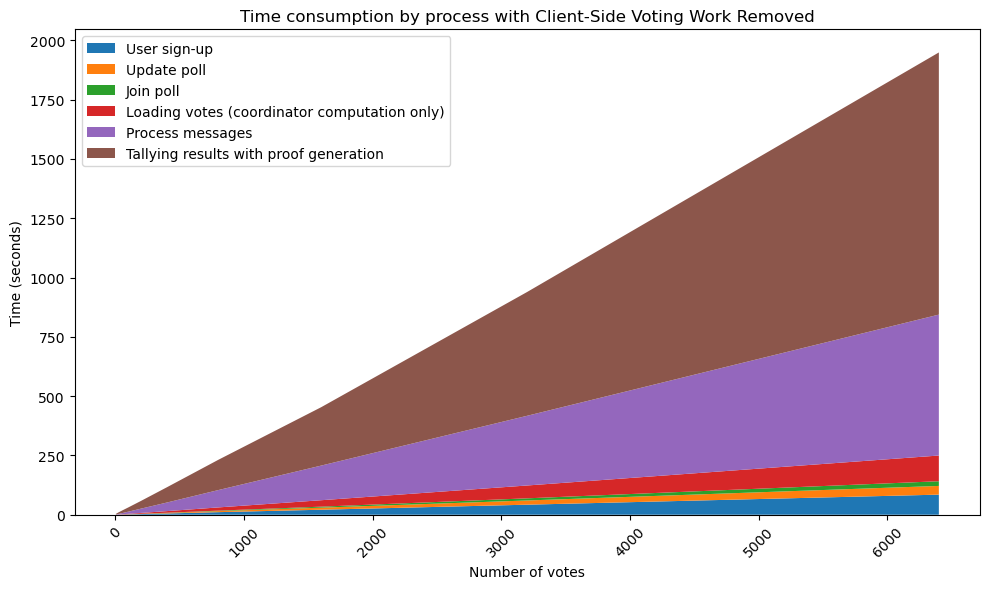

Saved pie chart to /Users/joshuab/Software/Uni/ENGGEN700/maci/packages/contracts/final_python_visualisations/results_numUsers_6400.png


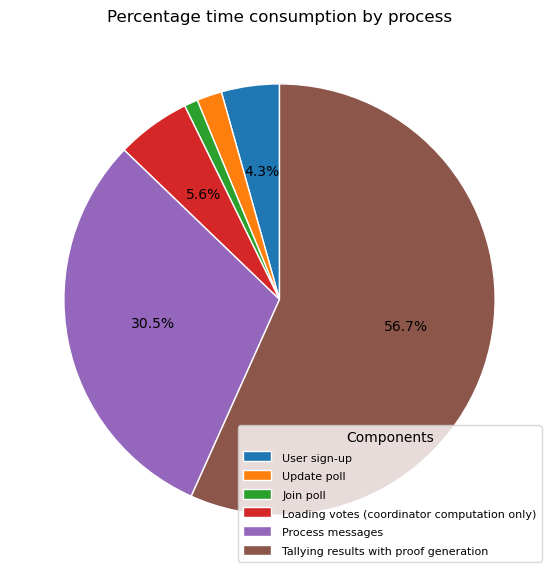

Saved pie chart to /Users/joshuab/Software/Uni/ENGGEN700/maci/packages/contracts/final_python_visualisations/results_para_numUsers_6400.png


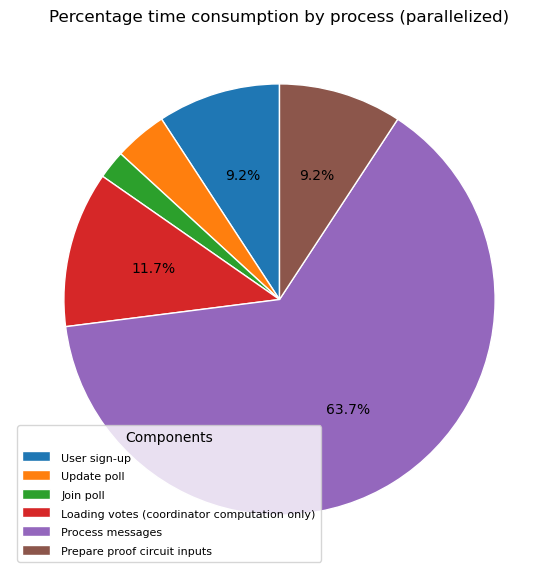

In [6]:
PROOF_BENCH_2_TITLE = "Time consumption by process with Client-Side Voting Work Removed"
PROOF_BENCH_2_FIELDS = {
    "SIGN_UP": "User sign-up",
    "UPDATE_POLL": "Update poll",
    "JOIN_POLL": "Join poll",
    "TOTAL_VALID_VOTES": "Loading votes (coordinator computation only)",
    "PROCESS_MESSAGES": "Process messages",
    "TALLY_PROOFS": "Tallying results with proof generation",
}
plot(PROOF_BENCH_2_OUTPUT_FILE, PROOF_BENCH_2_TITLE, PROOF_BENCH_2_FIELDS)
plot_pie(PROOF_BENCH_2_OUTPUT_FILE, PROOF_BENCH_2_FIELDS, 6400, "Percentage time consumption by process", Path("results.json"))

PARALLEL_BENCH_FIELDS = PROOF_BENCH_2_FIELDS.copy()
del PARALLEL_BENCH_FIELDS["TALLY_PROOFS"]
PARALLEL_BENCH_FIELDS["SAVE_CIRCUIT_INPUTS"] = "Prepare proof circuit inputs"

plot_pie(PROOF_BENCH_3_OUTPUT_FILE, PARALLEL_BENCH_FIELDS, 6400, "Percentage time consumption by process (parallelized)", Path("results_para.json"))


# Now extrapolate to 5 million votes

In [8]:
NUM_VOTES_TO_USE_AS_INPUT = 50

def print_seconds(seconds ):
    # if seconds > 86400:
        print(f"{seconds / 86400:.2f} days")
    # if seconds > 604800:
        print(f"Or about {seconds / 604800:.2f} weeks")

def extrapolate_to_n_votes(filename, fields, n, modifiers=dict()):
    results = load_results(Path(filename))
    x, stacks = extract_series(results, list(fields.keys()))

    for i, num in enumerate(x):
        if num == NUM_VOTES_TO_USE_AS_INPUT:
            scale_factor = n / float(NUM_VOTES_TO_USE_AS_INPUT)
            extrapolated_stack = [v[i] * scale_factor for v in stacks] 

            for j, key in enumerate(fields.keys()):
                if key in modifiers:
                    extrapolated_stack[j] = modifiers[key] * extrapolated_stack[j]
            return n, extrapolated_stack

    raise ValueError(f"Could not find data for {NUM_VOTES_TO_USE_AS_INPUT} votes in {filename}")


EXTRAPOLATE_FIELDS = PROOF_BENCH_2_FIELDS
EXTRAPOLATE_FIELDS["MP_PROOFS"] = "Message processing proofs"

n, extrapolated_stack = extrapolate_to_n_votes(PROOF_BENCH_2_OUTPUT_FILE, EXTRAPOLATE_FIELDS, 5_000_000)
print(f"Non Parallel Time for {n} votes:")
non_parallel_seconds = sum(extrapolated_stack)
print_seconds(non_parallel_seconds)


PARALLEL_EXTRAPOLATE_FIELDS = EXTRAPOLATE_FIELDS.copy()
del PARALLEL_EXTRAPOLATE_FIELDS["TALLY_PROOFS"]
PARALLEL_EXTRAPOLATE_FIELDS["SAVE_CIRCUIT_INPUTS"] = "Prepare proof circuit inputs"


n, parallel_extrapolated_stack = extrapolate_to_n_votes(PROOF_BENCH_3_OUTPUT_FILE, PARALLEL_EXTRAPOLATE_FIELDS, 5_000_000)
print(f"\nParallel Time for {n} votes:")
parallel_seconds = sum(parallel_extrapolated_stack)
print_seconds(parallel_seconds)


def process_messages_speedup(speedup: float):
    modifiers = {"PROCESS_MESSAGES": 1/speedup} # assume 1.5x speed up due to parallelism
    n, modified_parallel_extrapolated_stack = extrapolate_to_n_votes(PROOF_BENCH_3_OUTPUT_FILE, PARALLEL_EXTRAPOLATE_FIELDS, 5_000_000, modifiers=modifiers)
    print(f"\n{speedup}x message processing time for {n} votes:")
    parallel_seconds = sum(modified_parallel_extrapolated_stack)
    print_seconds(parallel_seconds)

process_messages_speedup(1.5)
process_messages_speedup(2.0)
process_messages_speedup(3.0)
process_messages_speedup(4.0)
process_messages_speedup(5.0)

Non Parallel Time for 5000000 votes:
20.05 days
Or about 2.86 weeks

Parallel Time for 5000000 votes:
8.89 days
Or about 1.27 weeks

1.5x message processing time for 5000000 votes:
7.15 days
Or about 1.02 weeks

2.0x message processing time for 5000000 votes:
6.29 days
Or about 0.90 weeks

3.0x message processing time for 5000000 votes:
5.42 days
Or about 0.77 weeks

4.0x message processing time for 5000000 votes:
4.98 days
Or about 0.71 weeks

5.0x message processing time for 5000000 votes:
4.72 days
Or about 0.67 weeks


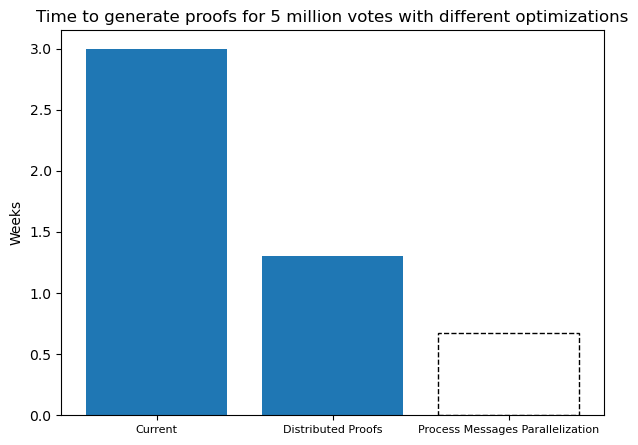

In [ ]:
import matplotlib.pyplot as plt

# Example values
values = [3, 1.3, 0.67]

# Prompt user for titles
titles = ["Current", "Distributed Proofs", "Process Messages Parallelization"]

plt.figure(figsize=(7, 5))
colors = ['#1f77b4', '#1f77b4', "#ff7e0e00"]  # blue, green, orange
bars = plt.bar(titles, values, color=colors)
bars[2].set_linestyle('--')
for tick in plt.gca().get_xticklabels():
    tick.set_fontsize(8)
bars[2].set_edgecolor('black')
plt.ylabel("Weeks")
plt.title("Time to generate proofs for 5 million votes with different optimizations")
plt.savefig("bar_chart.png", dpi=300, transparent=True)
plt.show()